In [1]:
import pandas as pd
import sqlite3

In [2]:
connection = sqlite3.connect('../data/checking-logs.sqlite')

In [3]:
pd.read_sql("SELECT * FROM pageviews LIMIT 5", connection)

,index,uid,datetime
0,0,admin_1,2020-04-17 12:01:08.463179
1,1,admin_1,2020-04-17 12:01:23.743946
2,2,admin_3,2020-04-17 12:17:39.287778
3,3,admin_3,2020-04-17 12:17:40.001768
4,4,admin_1,2020-04-17 12:27:30.646665


In [4]:
df = pd.read_sql("SELECT datetime FROM pageviews WHERE uid LIKE 'user%'", connection)
df

,datetime
0,2020-04-17 22:46:26.785035
1,2020-04-18 10:53:52.623447
2,2020-04-18 10:56:55.833899
3,2020-04-18 10:57:37.331258
4,2020-04-18 12:05:48.200144
...,...
982,2020-05-21 18:45:20.441142
983,2020-05-21 23:03:06.457819
984,2020-05-21 23:23:49.995349
985,2020-05-22 11:30:18.368990


In [5]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['date'] = df['datetime'].dt.date
df

,datetime,date
0,2020-04-17 22:46:26.785035,2020-04-17
1,2020-04-18 10:53:52.623447,2020-04-18
2,2020-04-18 10:56:55.833899,2020-04-18
3,2020-04-18 10:57:37.331258,2020-04-18
4,2020-04-18 12:05:48.200144,2020-04-18
...,...,...
982,2020-05-21 18:45:20.441142,2020-05-21
983,2020-05-21 23:03:06.457819,2020-05-21
984,2020-05-21 23:23:49.995349,2020-05-21
985,2020-05-22 11:30:18.368990,2020-05-22


In [6]:
visits = df.groupby('date').size().reset_index(name='visits')
visits

,date,visits
0,2020-04-17,1
1,2020-04-18,23
2,2020-04-19,15
3,2020-04-21,3
4,2020-04-22,1
5,2020-04-23,5
6,2020-04-25,1
7,2020-04-26,8
8,2020-04-28,2
9,2020-04-29,4


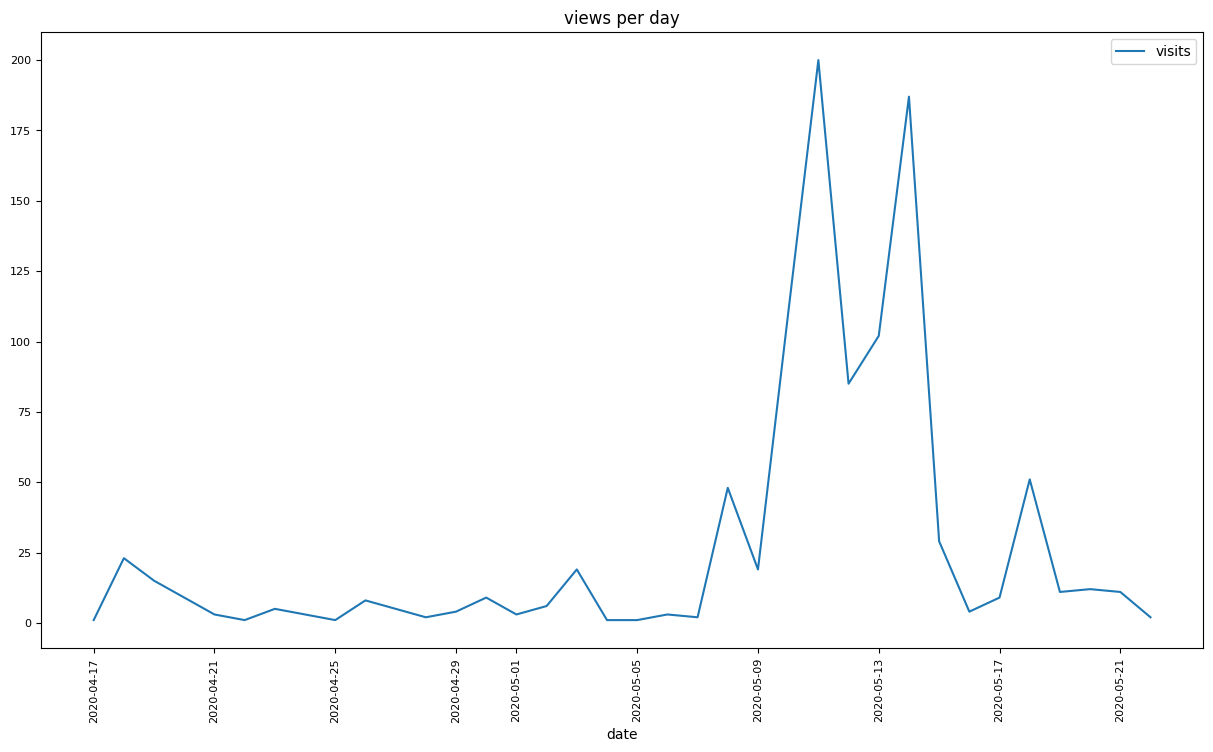

In [7]:
graph = visits.plot(kind='line', figsize=(15, 8), x='date', y='visits', title='views per day', fontsize=8)
graph.tick_params(axis='x', rotation=90)

In [8]:
connection.close()